# EDA and Cleaning (10 pts)
- This notebook should contain all necessary data organization steps and notes of why each
step was taken.
- Visualize the raw data as necessary and informative to cleaning steps.
- Also keep track (in comments) what the loss in number of observations is and why.
- The final step of this notebook should export your Cleaned Data set to a new _cleaned.csv
file AND export your Train/Test split to p pickle files to import in each of your following
notebooks.

# THIS IS THE ONE WITH THE EXTRA COLUMNS REMOVED

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Loan_Default.csv")

## Get the head to get the idea of the data
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## EDA 

#### The Interest_rate_Spread, rate_of_interest, Upfront_charges, property_value are all extremely correlated with the status. 
#### Becuase of this, we got almost perfect accuracies and models.
#### We want to drop these columns right away

In [49]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [50]:
df.shape

(148670, 34)

In [51]:
## From the get go, we can drop ID and year columns as they are not useful for our analysis
df.drop(columns=["ID", "year", "Interest_rate_spread","rate_of_interest","Upfront_charges","property_value"], inplace=True)

In [52]:
## Find the number of duplicated rows (0)
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 1


In [53]:
df.drop_duplicates(inplace=True)

In [54]:
## get the shape of the data (148670 rows, 32 columns)
shape=df.shape
print(f"Shape of the DataFrame: {shape}")

Shape of the DataFrame: (148669, 28)


In [55]:
##find the number of missing values in each column
df.isnull().sum().sort_values(ascending=False)

dtir1                        24120
LTV                          15098
income                        9149
loan_limit                    3344
approv_in_adv                  908
submission_of_application      200
age                            200
loan_purpose                   134
Neg_ammortization              121
term                            41
loan_type                        0
Gender                           0
interest_only                    0
loan_amount                      0
open_credit                      0
business_or_commercial           0
Credit_Worthiness                0
lump_sum_payment                 0
occupancy_type                   0
construction_type                0
Credit_Score                     0
credit_type                      0
total_units                      0
Secured_by                       0
co-applicant_credit_type         0
Region                           0
Security_Type                    0
Status                           0
dtype: int64

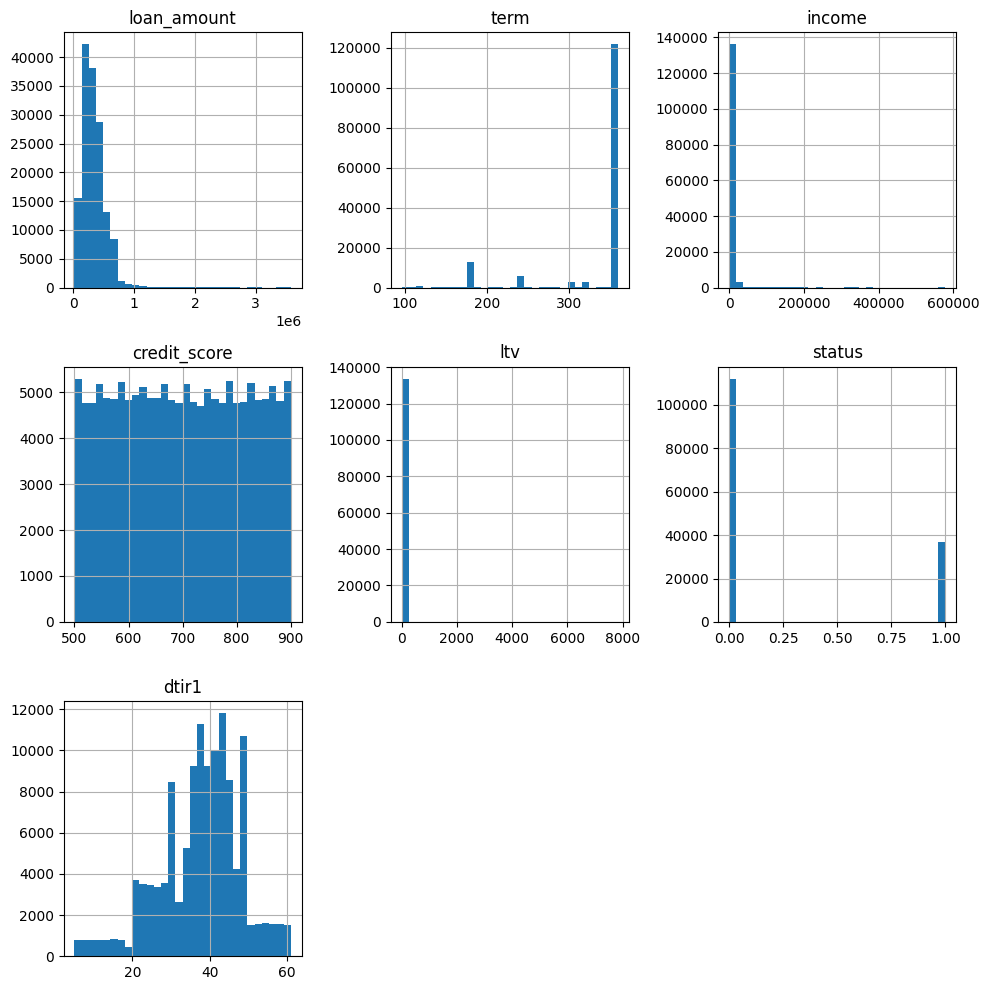

In [56]:
## Make the columns more readable by making them lowercase and replacing spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

## Create a histogram to view the distribution of each column and identify outliers
df.hist(bins=30, figsize=(10, 10))
plt.tight_layout()

In [57]:
## use df.describe() to get a summary of the data
df.describe()

,loan_amount,term,income,credit_score,ltv,status,dtir1
count,1.486690e+05,148628.000000,139520.000000,148669.000000,133571.000000,148669.000000,124549.000000
mean,3.311184e+05,335.136414,6957.338876,699.790010,72.746365,0.246447,37.732932
std,1.839098e+05,58.409244,6496.586382,115.875719,39.967738,0.430943,10.545435
min,1.650000e+04,96.000000,0.000000,500.000000,0.967478,0.000000,5.000000
25%,1.965000e+05,360.000000,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,2.965000e+05,360.000000,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,4.365000e+05,360.000000,8520.000000,800.000000,86.184211,0.000000,45.000000
max,3.576500e+06,360.000000,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [58]:
## Outliers are top 1% of loan_amount, rate_of_interest, interest_rate_spread, upfront_charges, property_value, ltv
## and bottom 1% of interest_rate_spread,

In [59]:
df.describe(include='all')

,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,term,...,credit_type,credit_score,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1
count,145325,148669,147761,148669,148535,148669,148669,148669,1.486690e+05,148628.000000,...,148669,148669.000000,148669,148469,148469,133571.000000,148669,148669,148669.000000,124549.000000
unique,2,4,2,3,4,2,2,2,NaN,NaN,...,4,NaN,2,7,2,NaN,4,2,NaN,NaN
top,cf,Male,nopre,type1,p3,l1,nopc,nob/c,NaN,NaN,...,CIB,NaN,CIB,45-54,to_inst,NaN,North,direct,NaN,NaN
freq,135347,42346,124620,113173,55934,142343,148113,127908,NaN,NaN,...,48152,NaN,74391,34720,95813,NaN,74722,148636,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.311184e+05,335.136414,...,NaN,699.790010,NaN,NaN,NaN,72.746365,NaN,NaN,0.246447,37.732932
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.839098e+05,58.409244,...,NaN,115.875719,NaN,NaN,NaN,39.967738,NaN,NaN,0.430943,10.545435
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.650000e+04,96.000000,...,NaN,500.000000,NaN,NaN,NaN,0.967478,NaN,NaN,0.000000,5.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.965000e+05,360.000000,...,NaN,599.000000,NaN,NaN,NaN,60.474860,NaN,NaN,0.000000,31.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.965000e+05,360.000000,...,NaN,699.000000,NaN,NaN,NaN,75.135870,NaN,NaN,0.000000,39.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.365000e+05,360.000000,...,NaN,800.000000,NaN,NaN,NaN,86.184211,NaN,NaN,0.000000,45.000000


In [60]:
df['gender'].value_counts()

gender
Male                 42346
Joint                41399
Sex Not Available    37658
Female               27266
Name: count, dtype: int64

In [61]:
df.isnull().sum().sort_values(ascending=False)
##loan limit, interest rate, and loan term have missing values. However, since there are 

dtir1                        24120
ltv                          15098
income                        9149
loan_limit                    3344
approv_in_adv                  908
submission_of_application      200
age                            200
loan_purpose                   134
neg_ammortization              121
term                            41
loan_type                        0
gender                           0
interest_only                    0
loan_amount                      0
open_credit                      0
business_or_commercial           0
credit_worthiness                0
lump_sum_payment                 0
occupancy_type                   0
construction_type                0
credit_score                     0
credit_type                      0
total_units                      0
secured_by                       0
co-applicant_credit_type         0
region                           0
security_type                    0
status                           0
dtype: int64

In [62]:
df.shape
## (148670, 34) we only lost 1 row that was a duplicate

(148669, 28)

## Data Cleaning

### Remove/Replace null rows

In [63]:
## after some inital research, we want to drop open_credit, Secured_by, Security_Type since they are not useful
dfclean = df.copy()
dfclean.drop(columns=["open_credit", "secured_by", "security_type"], inplace=True)
dfclean.shape ## we have 148670 rows and 29 columns now that we dropped 3

(148669, 25)

In [64]:
## The columns with missing values are:
# upfront_charges - initial charges with securing a loan - replace with median
# interest_rate_spread - interest rate difference between the loan and the market rate - replace with median
# rate_of_interest - interest rate on the loan - replace with median
# dtir1 - debt to income ratio - negative since there could be no income
# property_value - value of the property being financed - replace with negative since there could be no property value
# ltv - loan to value ratio, loan amount/property_value - replace with negative since there could be no property value
# income - income - replace with negative since there could be no income
# loan_limit - 




# approv_in_adv is the first with under 1000 missing values, so we will just drop them             
# approv_in_adv                  
# age                            
# submission_of_application      
# loan_purpose                   
# neg_ammortization              
# term                            

In [65]:
## replace "dtir1", "property_value", "income" with -1 instead of with the median because those are likely intenitonally left out since they deal with income and property value
## there may not be any income and a property may not be what is being financed
replace=["dtir1", "income","ltv"]
   
for col in replace:
    dfclean[col] = dfclean[col].fillna(-1)

In [66]:
dfclean.shape ## no columns or rows were dropped

(148669, 25)

In [67]:
# for loan limit, it is either conforming or non conforming. 
# For that, just replace it with the mode (in this case cf)
df['loan_limit'].value_counts()

loan_limit
cf     135347
ncf      9978
Name: count, dtype: int64

In [68]:
## update the loan_limit column with the mode value of the column (cf)
dfclean['loan_limit'] = dfclean['loan_limit'].fillna(dfclean['loan_limit'].mode()[0])

In [69]:
##drop the remaining missing values in the dataset
dfclean=dfclean.dropna()
dfclean.shape ## (148669, 34) we only lost 1396 rows (0.9% of the data) which is not bad

(147273, 25)

In [70]:
## check if there are any more missing values in the dataset just incase
dfclean.isna().sum().sort_values(ascending=False)

loan_limit                   0
gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
credit_worthiness            0
business_or_commercial       0
loan_amount                  0
term                         0
neg_ammortization            0
interest_only                0
lump_sum_payment             0
construction_type            0
occupancy_type               0
total_units                  0
income                       0
credit_type                  0
credit_score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
ltv                          0
region                       0
status                       0
dtir1                        0
dtype: int64

### Remove Outliers

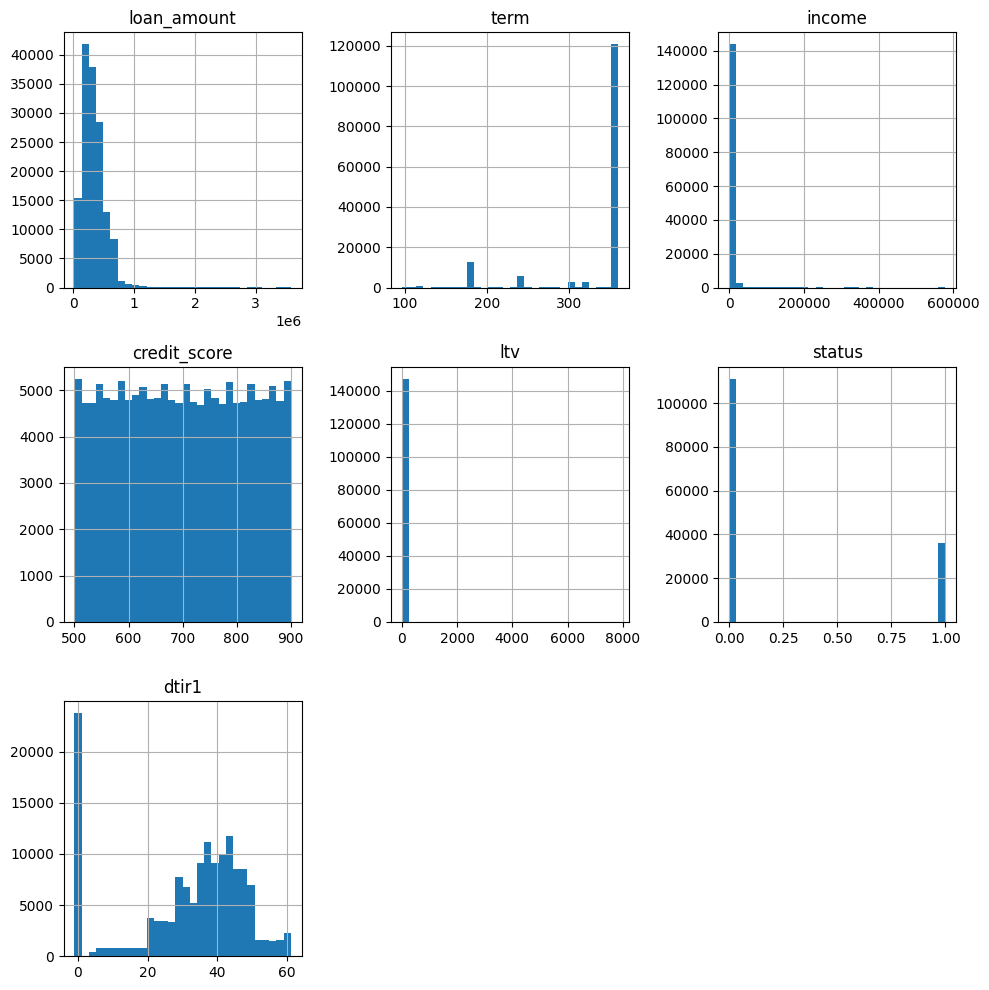

In [71]:
## create another histogram to look at the outliers again now that we replaced the missing values and removed null columns
dfclean.hist(bins=30, figsize=(10, 10))
plt.tight_layout()

In [72]:
dfclean.describe()

,loan_amount,term,income,credit_score,ltv,status,dtir1
count,1.472730e+05,147273.000000,147273.000000,147273.000000,147273.000000,147273.000000,147273.000000
mean,3.314397e+05,335.141017,6536.117978,699.754748,65.243692,0.245286,31.484841
std,1.838113e+05,58.420992,6516.579057,115.866838,44.067061,0.430258,17.211318
min,1.650000e+04,96.000000,-1.000000,500.000000,-1.000000,0.000000,-1.000000
25%,1.965000e+05,360.000000,3360.000000,599.000000,54.483122,0.000000,23.000000
50%,2.965000e+05,360.000000,5460.000000,699.000000,73.026316,0.000000,37.000000
75%,4.365000e+05,360.000000,8280.000000,800.000000,84.698997,0.000000,44.000000
max,3.576500e+06,360.000000,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [73]:
## we need to take out the top 1% of the data for the loan_amount, rate_of_interest, interest_rate_spread, upfront_charges, income, property_value, ltv 
## we need to take out the bottom 1% of rate_of_interest, interest_rate_spread, ltv, 
colcleantop=["loan_amount", "ltv",'income']
for col in colcleantop:
    dfclean = dfclean[dfclean[col] < dfclean[col].quantile(0.985)]

colcleanbottom=["ltv"]
for col in colcleanbottom:
    dfclean = dfclean[dfclean[col] > dfclean[col].quantile(0.01)]


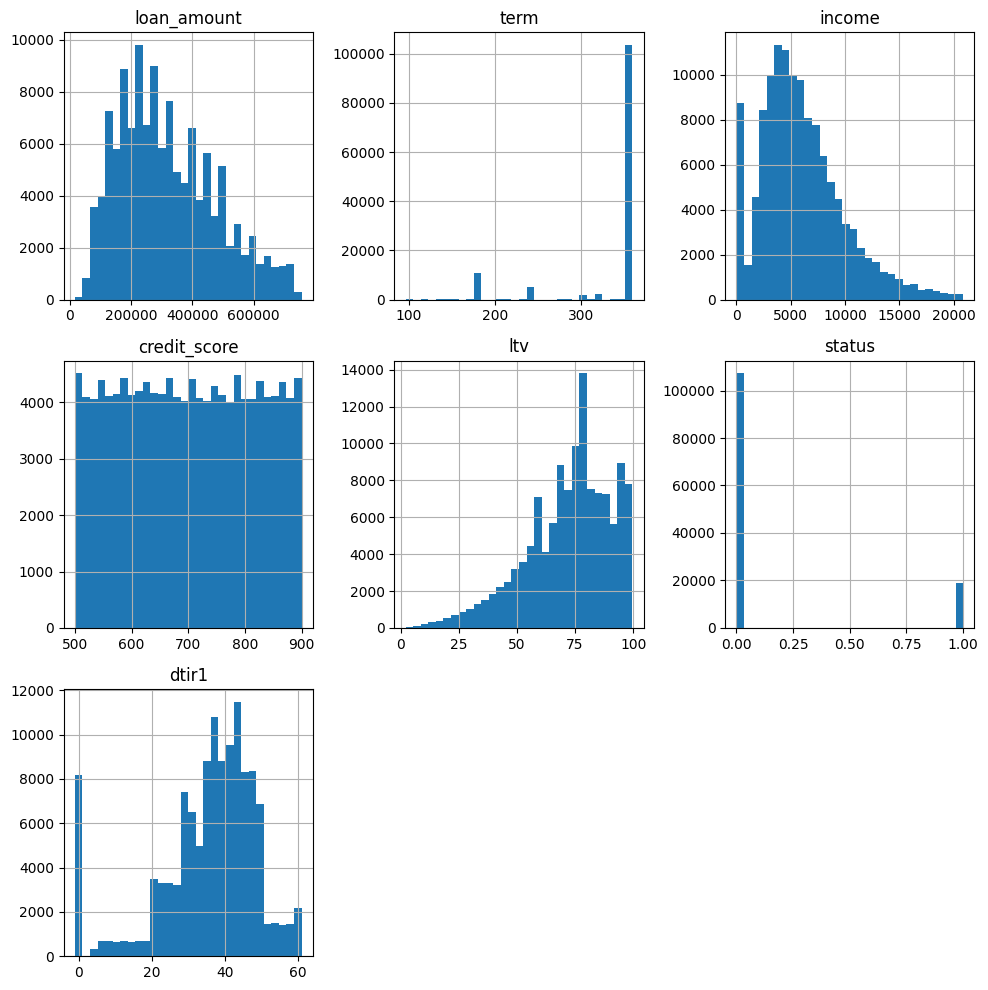

In [74]:
## create another histogram to look at the data without outliers and null values
dfclean.hist(bins=30, figsize=(10, 10))
plt.tight_layout()

## Dummy/Train Test Split

### Make Booleans 

In [75]:
## look into the description of the categorical columns
# Select only categorical columns to make them dummy variables
categorical_columns = dfclean.select_dtypes(include=['object', 'category'])

# Call describe() on the filtered DataFrame
categorical_columns.describe()

,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,business_or_commercial,neg_ammortization,interest_only,lump_sum_payment,construction_type,occupancy_type,total_units,credit_type,co-applicant_credit_type,age,submission_of_application,region
count,126281,126281,126281,126281,126281,126281,126281,126281,126281,126281,126281,126281,126281,126281,126281,126281,126281,126281
unique,2,4,2,3,4,2,2,2,2,2,2,3,4,4,2,7,2,4
top,cf,Male,nopre,type1,p3,l1,nob/c,not_neg,not_int,not_lpsm,sb,pr,1U,CIB,CIB,45-54,to_inst,North
freq,119847,35685,106182,97404,49085,121131,108540,114577,120590,124231,126249,117966,124671,45433,71112,29366,81325,63938


In [76]:
## look at all of the columns including categorical columns
dfclean.describe(include='all')

,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,business_or_commercial,loan_amount,term,neg_ammortization,...,income,credit_type,credit_score,co-applicant_credit_type,age,submission_of_application,ltv,region,status,dtir1
count,126281,126281,126281,126281,126281,126281,126281,126281.000000,126281.000000,126281,...,126281.000000,126281,126281.000000,126281,126281,126281,126281.000000,126281,126281.000000,126281.000000
unique,2,4,2,3,4,2,2,NaN,NaN,2,...,NaN,4,NaN,2,7,2,NaN,4,NaN,NaN
top,cf,Male,nopre,type1,p3,l1,nob/c,NaN,NaN,not_neg,...,NaN,CIB,NaN,CIB,45-54,to_inst,NaN,North,NaN,NaN
freq,119847,35685,106182,97404,49085,121131,108540,NaN,NaN,114577,...,NaN,45433,NaN,71112,29366,81325,NaN,63938,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,319138.084906,335.194764,NaN,...,5996.859005,NaN,699.561850,NaN,NaN,NaN,72.156267,NaN,0.150997,35.393923
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158525.383905,58.415217,NaN,...,3846.342506,NaN,115.878263,NaN,NaN,NaN,18.429923,NaN,0.358047,13.843520
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16500.000000,96.000000,NaN,...,-1.000000,NaN,500.000000,NaN,NaN,NaN,2.072943,NaN,0.000000,-1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,196500.000000,360.000000,NaN,...,3360.000000,NaN,599.000000,NaN,NaN,NaN,60.416667,NaN,0.000000,30.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,296500.000000,360.000000,NaN,...,5400.000000,NaN,699.000000,NaN,NaN,NaN,75.102459,NaN,0.000000,38.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,426500.000000,360.000000,NaN,...,8040.000000,NaN,800.000000,NaN,NaN,NaN,85.614525,NaN,0.000000,44.000000


In [77]:
## status is our dependent variable
## 1 is default and 0 is not default
dfclean['status'].value_counts()

status
0    107213
1     19068
Name: count, dtype: int64

In [78]:
dfclean.columns

Index(['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'credit_worthiness', 'business_or_commercial', 'loan_amount', 'term',
       'neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'total_units', 'income',
       'credit_type', 'credit_score', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'ltv', 'region', 'status', 'dtir1'],
      dtype='object')

In [79]:
## Columns that need to be converted to dummy variables. These are all of the ones that are above.
booleanvar = ['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'credit_worthiness', 'business_or_commercial', 'neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'region']

dep_var = ['status'] ## 1 is defaulted, 0 is not

X=dfclean.copy()

y = X[dep_var]

X = pd.get_dummies(X, columns = booleanvar,
                      drop_first=False,
                      dtype=int)



In [80]:
X.head()

,loan_amount,term,income,credit_score,ltv,status,dtir1,loan_limit_cf,loan_limit_ncf,gender_Female,...,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_not_inst,submission_of_application_to_inst,region_North,region_North-East,region_central,region_south
0,116500,360.0,1740.0,758,98.728814,1,45.0,1,0,0,...,0,0,0,0,0,1,0,0,0,1
2,406500,360.0,9480.0,834,80.019685,0,46.0,1,0,0,...,0,0,0,0,0,1,0,0,0,1
3,456500,360.0,11880.0,587,69.376900,0,42.0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
4,696500,360.0,10440.0,602,91.886544,0,39.0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
5,706500,360.0,10080.0,864,70.089286,0,40.0,1,0,0,...,0,0,0,0,1,0,1,0,0,0


In [81]:
X.drop(columns=dep_var, inplace=True)

In [82]:
X.columns

Index(['loan_amount', 'term', 'income', 'credit_score', 'ltv', 'dtir1',
       'loan_limit_cf', 'loan_limit_ncf', 'gender_Female', 'gender_Joint',
       'gender_Male', 'gender_Sex Not Available', 'approv_in_adv_nopre',
       'approv_in_adv_pre', 'loan_type_type1', 'loan_type_type2',
       'loan_type_type3', 'loan_purpose_p1', 'loan_purpose_p2',
       'loan_purpose_p3', 'loan_purpose_p4', 'credit_worthiness_l1',
       'credit_worthiness_l2', 'business_or_commercial_b/c',
       'business_or_commercial_nob/c', 'neg_ammortization_neg_amm',
       'neg_ammortization_not_neg', 'interest_only_int_only',
       'interest_only_not_int', 'lump_sum_payment_lpsm',
       'lump_sum_payment_not_lpsm', 'construction_type_mh',
       'construction_type_sb', 'occupancy_type_ir', 'occupancy_type_pr',
       'occupancy_type_sr', 'total_units_1U', 'total_units_2U',
       'total_units_3U', 'total_units_4U', 'credit_type_CIB',
       'credit_type_CRIF', 'credit_type_EQUI', 'credit_type_EXP',
       '

### Make Train Test Split

In [83]:
## Make an 80/20 split of the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size = 0.2,
                                                    random_state=42)

## Make a pickle file

In [84]:
import pickle

dfclean.to_pickle('dfclean.pkl')

data = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'y_test': y_test
}

# Save to file
with open('finaldataset.pkl', 'wb') as f:
    pickle.dump(data, f)

TO UNPICKLE

with open('dataset.pkl', 'rb') as f:
    data = pickle.load(f)

# Extract the components
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']